# Flow Matching Velocity Field Visualization

This notebook visualizes how flow matching transforms a simple Gaussian distribution into a target distribution by learning a time-dependent velocity field.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import LinearSegmentedColormap
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp
from tqdm.auto import tqdm

# Force CPU
device = torch.device('cpu')
torch.manual_seed(42)
np.random.seed(42)

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

## 1. Define Target Distribution

We'll use a mixture of Gaussians as our target distribution - this creates an interesting multi-modal target.

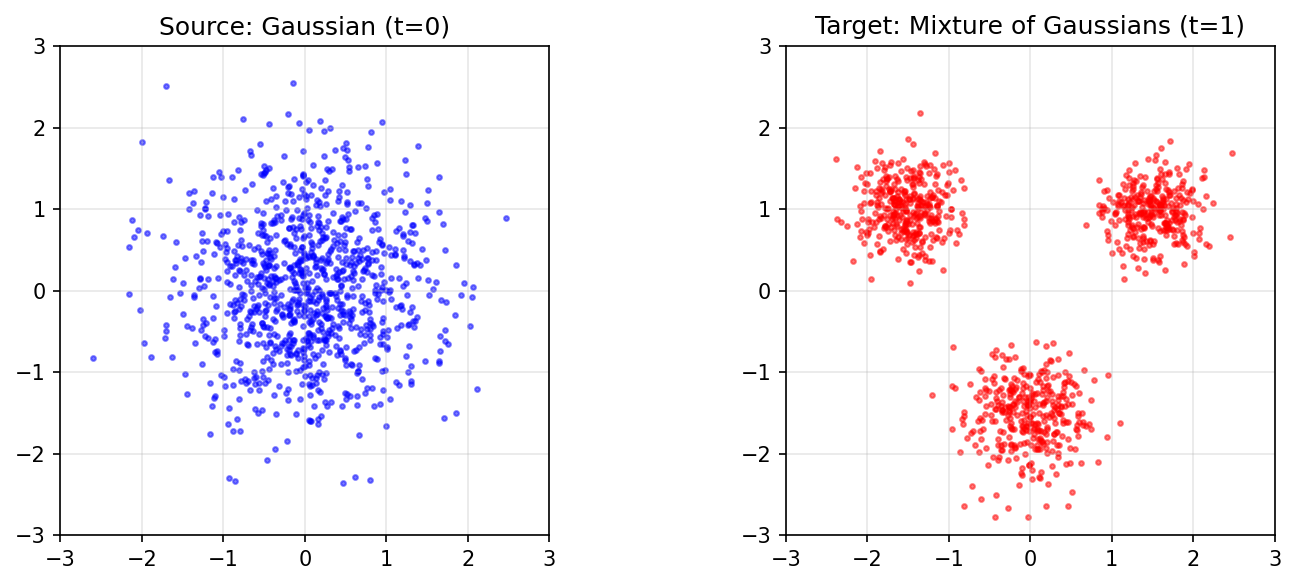

In [2]:
# Target distribution: mixture of 3 Gaussians
def sample_target(n_samples):
    """Sample from target distribution (mixture of Gaussians)."""
    centers = np.array([
        [-1.5, 1.0],
        [1.5, 1.0],
        [0.0, -1.5]
    ])
    stds = [0.3, 0.3, 0.4]
    
    # Randomly assign each sample to a cluster
    assignments = np.random.choice(3, size=n_samples, p=[0.33, 0.33, 0.34])
    
    samples = np.zeros((n_samples, 2))
    for i, (center, std) in enumerate(zip(centers, stds)):
        mask = assignments == i
        n = mask.sum()
        samples[mask] = np.random.randn(n, 2) * std + center
    
    return samples

# Source distribution: standard Gaussian
def sample_source(n_samples):
    """Sample from source distribution (standard Gaussian)."""
    return np.random.randn(n_samples, 2) * 0.8

# Visualize both distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

source_samples = sample_source(1000)
target_samples = sample_target(1000)

axes[0].scatter(source_samples[:, 0], source_samples[:, 1], s=5, alpha=0.5, c='blue')
axes[0].set_xlim(-3, 3)
axes[0].set_ylim(-3, 3)
axes[0].set_title('Source: Gaussian (t=0)')
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(target_samples[:, 0], target_samples[:, 1], s=5, alpha=0.5, c='red')
axes[1].set_xlim(-3, 3)
axes[1].set_ylim(-3, 3)
axes[1].set_title('Target: Mixture of Gaussians (t=1)')
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Flow Matching Model

Train a neural network to predict the velocity field $v(x, t)$ that transforms the source to target.

Training:   0%|          | 0/2000 [00:00<?, ?it/s]

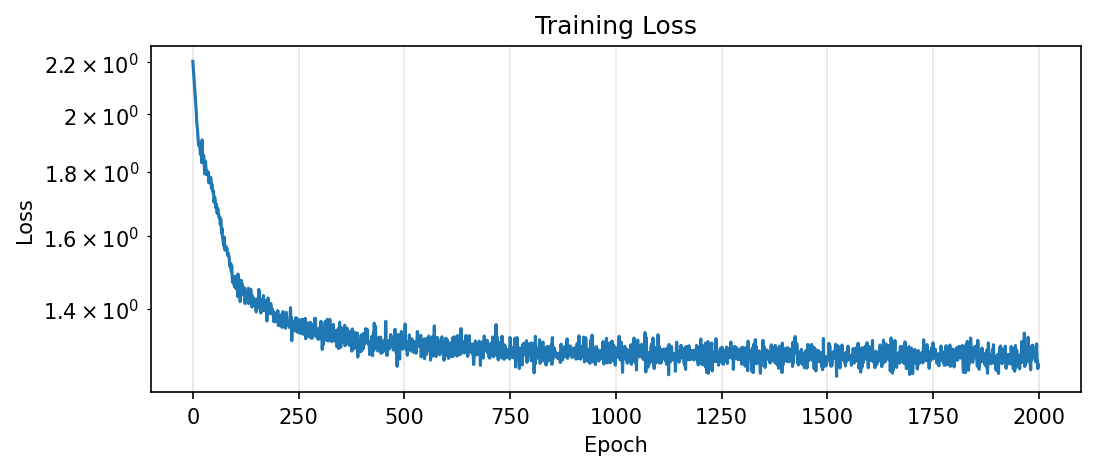

In [3]:
class VelocityNetwork(nn.Module):
    """Neural network that predicts velocity given position and time."""
    def __init__(self, dim=2, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, dim)
        )
    
    def forward(self, x, t):
        # x: (batch, dim), t: (batch, 1)
        t = t.view(-1, 1) if t.dim() == 1 else t
        inp = torch.cat([x, t], dim=-1)
        return self.net(inp)


def train_flow_matching(n_samples=10000, epochs=1000, lr=1e-3):
    """Train flow matching model using optimal transport conditional flows."""
    model = VelocityNetwork().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Generate paired samples
    x0 = torch.tensor(sample_source(n_samples), dtype=torch.float32, device=device)
    x1 = torch.tensor(sample_target(n_samples), dtype=torch.float32, device=device)
    
    losses = []
    pbar = tqdm(range(epochs), desc='Training')
    
    for epoch in pbar:
        optimizer.zero_grad()
        
        # Sample random times
        t = torch.rand(n_samples, 1, device=device)
        
        # Interpolate: x_t = (1-t)*x0 + t*x1
        x_t = (1 - t) * x0 + t * x1
        
        # Target velocity: dx/dt = x1 - x0 (constant for linear interpolation)
        v_target = x1 - x0
        
        # Predicted velocity
        v_pred = model(x_t, t)
        
        # MSE loss
        loss = ((v_pred - v_target) ** 2).mean()
        
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        if epoch % 100 == 0:
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return model, losses

# Train the model
model, losses = train_flow_matching(n_samples=5000, epochs=2000)

plt.figure(figsize=(8, 3))
plt.semilogy(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

## 3. Visualize Velocity Field at Different Times

Show how the velocity field evolves from t=0 to t=1.

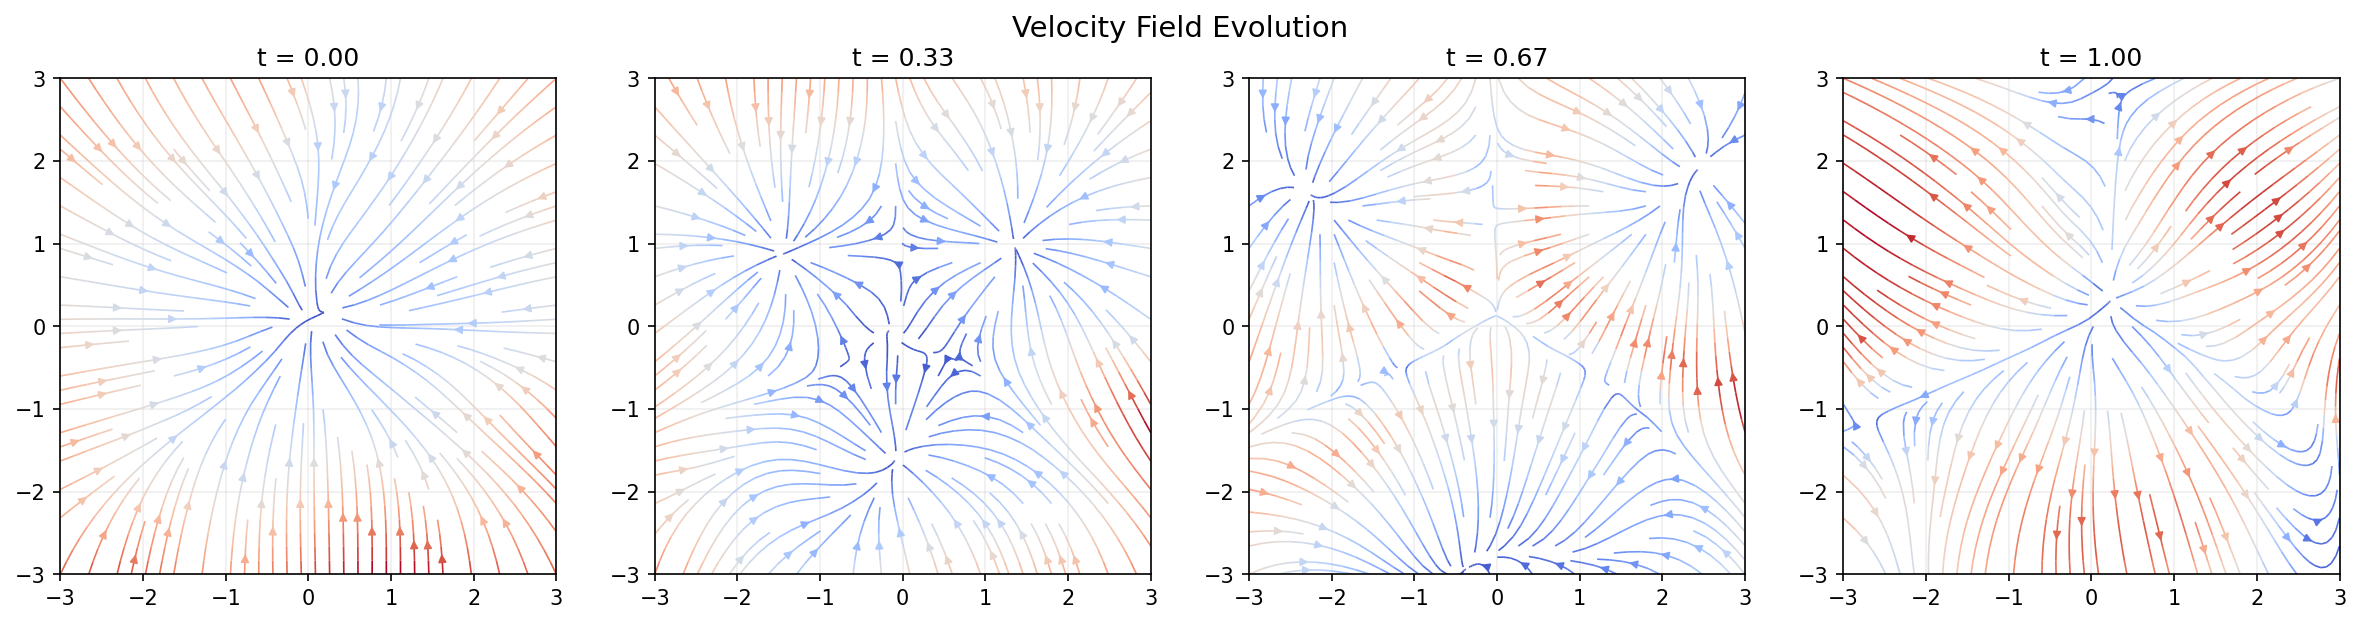

In [4]:
def plot_velocity_field(model, t_val, ax, n_grid=20):
    """Plot velocity field at time t."""
    # Create grid
    x = np.linspace(-3, 3, n_grid)
    y = np.linspace(-3, 3, n_grid)
    X, Y = np.meshgrid(x, y)
    
    # Flatten for batch processing
    points = np.column_stack([X.ravel(), Y.ravel()])
    points_t = torch.tensor(points, dtype=torch.float32, device=device)
    t = torch.full((len(points), 1), t_val, dtype=torch.float32, device=device)
    
    # Get velocities
    with torch.no_grad():
        v = model(points_t, t).cpu().numpy()
    
    U = v[:, 0].reshape(X.shape)
    V = v[:, 1].reshape(X.shape)
    
    # Compute magnitude for coloring
    magnitude = np.sqrt(U**2 + V**2)
    
    # Plot streamlines and quiver
    ax.streamplot(X, Y, U, V, color=magnitude, cmap='coolwarm', 
                  density=1.2, linewidth=0.8, arrowsize=0.8)
    
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.set_title(f't = {t_val:.2f}')
    ax.grid(True, alpha=0.2)

# Plot velocity fields at different times
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

times = [0.0, 0.33, 0.67, 1.0]
for ax, t in zip(axes, times):
    plot_velocity_field(model, t, ax)

plt.suptitle('Velocity Field Evolution', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Integration Paths (Particle Trajectories)

Show how individual particles flow from source to target by integrating the velocity field.

In [5]:
def integrate_trajectory(model, x0, n_steps=100):
    """Integrate a trajectory from t=0 to t=1."""
    def velocity(t, x):
        x_t = torch.tensor(x.reshape(1, -1), dtype=torch.float32, device=device)
        t_t = torch.tensor([[t]], dtype=torch.float32, device=device)
        with torch.no_grad():
            v = model(x_t, t_t).cpu().numpy().flatten()
        return v
    
    t_eval = np.linspace(0, 1, n_steps)
    sol = solve_ivp(velocity, [0, 1], x0, t_eval=t_eval, method='RK45')
    
    return sol.t, sol.y.T  # (n_steps, 2)

# Generate trajectories from random starting points
n_trajectories = 50
start_points = sample_source(n_trajectories)

trajectories = []
for x0 in tqdm(start_points, desc='Integrating trajectories'):
    t, traj = integrate_trajectory(model, x0)
    trajectories.append((t, traj))

print(f"Generated {len(trajectories)} trajectories")

Integrating trajectories:   0%|          | 0/50 [00:00<?, ?it/s]

Generated 50 trajectories


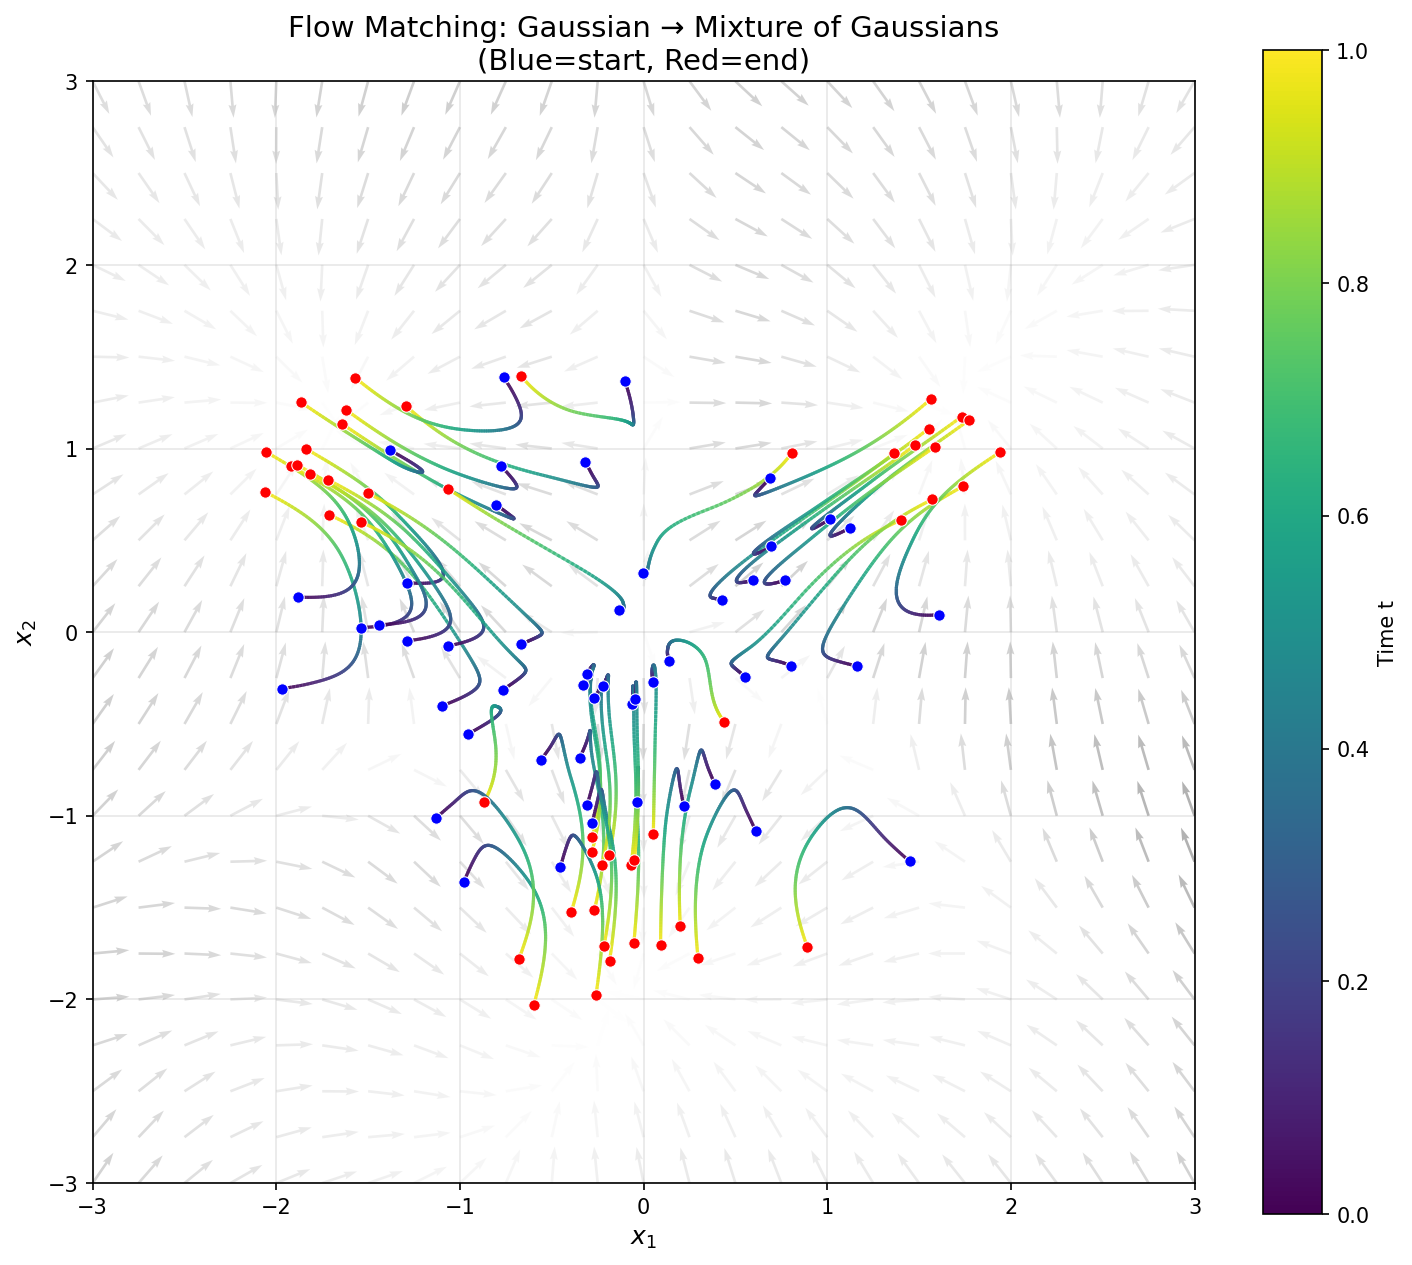

In [6]:
# Create the main visualization
fig, ax = plt.subplots(figsize=(10, 10))

# Plot velocity field at t=0.5 as background
x = np.linspace(-3, 3, 25)
y = np.linspace(-3, 3, 25)
X, Y = np.meshgrid(x, y)
points = np.column_stack([X.ravel(), Y.ravel()])
points_t = torch.tensor(points, dtype=torch.float32, device=device)
t_mid = torch.full((len(points), 1), 0.5, dtype=torch.float32, device=device)

with torch.no_grad():
    v = model(points_t, t_mid).cpu().numpy()

U = v[:, 0].reshape(X.shape)
V = v[:, 1].reshape(X.shape)
magnitude = np.sqrt(U**2 + V**2)

# Light quiver plot for background
ax.quiver(X, Y, U/magnitude, V/magnitude, magnitude, cmap='Greys', alpha=0.3, scale=30)

# Color map for time
cmap = plt.cm.viridis

# Plot trajectories with color gradient by time
for t, traj in trajectories:
    # Plot as line segments colored by time
    for i in range(len(t) - 1):
        color = cmap(t[i])
        ax.plot(traj[i:i+2, 0], traj[i:i+2, 1], c=color, lw=1.5, alpha=0.7)
    
    # Mark start and end points
    ax.scatter(traj[0, 0], traj[0, 1], c='blue', s=30, zorder=5, edgecolors='white', linewidths=0.5)
    ax.scatter(traj[-1, 0], traj[-1, 1], c='red', s=30, zorder=5, edgecolors='white', linewidths=0.5)

# Add colorbar for time
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
cbar = plt.colorbar(sm, ax=ax, label='Time t', shrink=0.8)

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xlabel('$x_1$', fontsize=12)
ax.set_ylabel('$x_2$', fontsize=12)
ax.set_title('Flow Matching: Gaussian → Mixture of Gaussians\n(Blue=start, Red=end)', fontsize=14)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Animated Snapshots of Distribution Evolution

Show the distribution at multiple time steps to see how it transforms.

In [7]:
def get_distribution_at_time(model, n_samples=500, t_target=0.5):
    """Get the distribution at intermediate time by integrating from t=0."""
    start_points = sample_source(n_samples)
    
    def velocity(t, x_flat):
        x = x_flat.reshape(-1, 2)
        x_t = torch.tensor(x, dtype=torch.float32, device=device)
        t_t = torch.full((len(x), 1), t, dtype=torch.float32, device=device)
        with torch.no_grad():
            v = model(x_t, t_t).cpu().numpy()
        return v.flatten()
    
    x0_flat = start_points.flatten()
    sol = solve_ivp(velocity, [0, t_target], x0_flat, method='RK45')
    
    return sol.y[:, -1].reshape(-1, 2)

# Get distributions at multiple times
times = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
distributions = {}

n_vis_samples = 800
distributions[0.0] = sample_source(n_vis_samples)

for t in tqdm(times[1:], desc='Computing distributions'):
    distributions[t] = get_distribution_at_time(model, n_vis_samples, t)

Computing distributions:   0%|          | 0/5 [00:00<?, ?it/s]

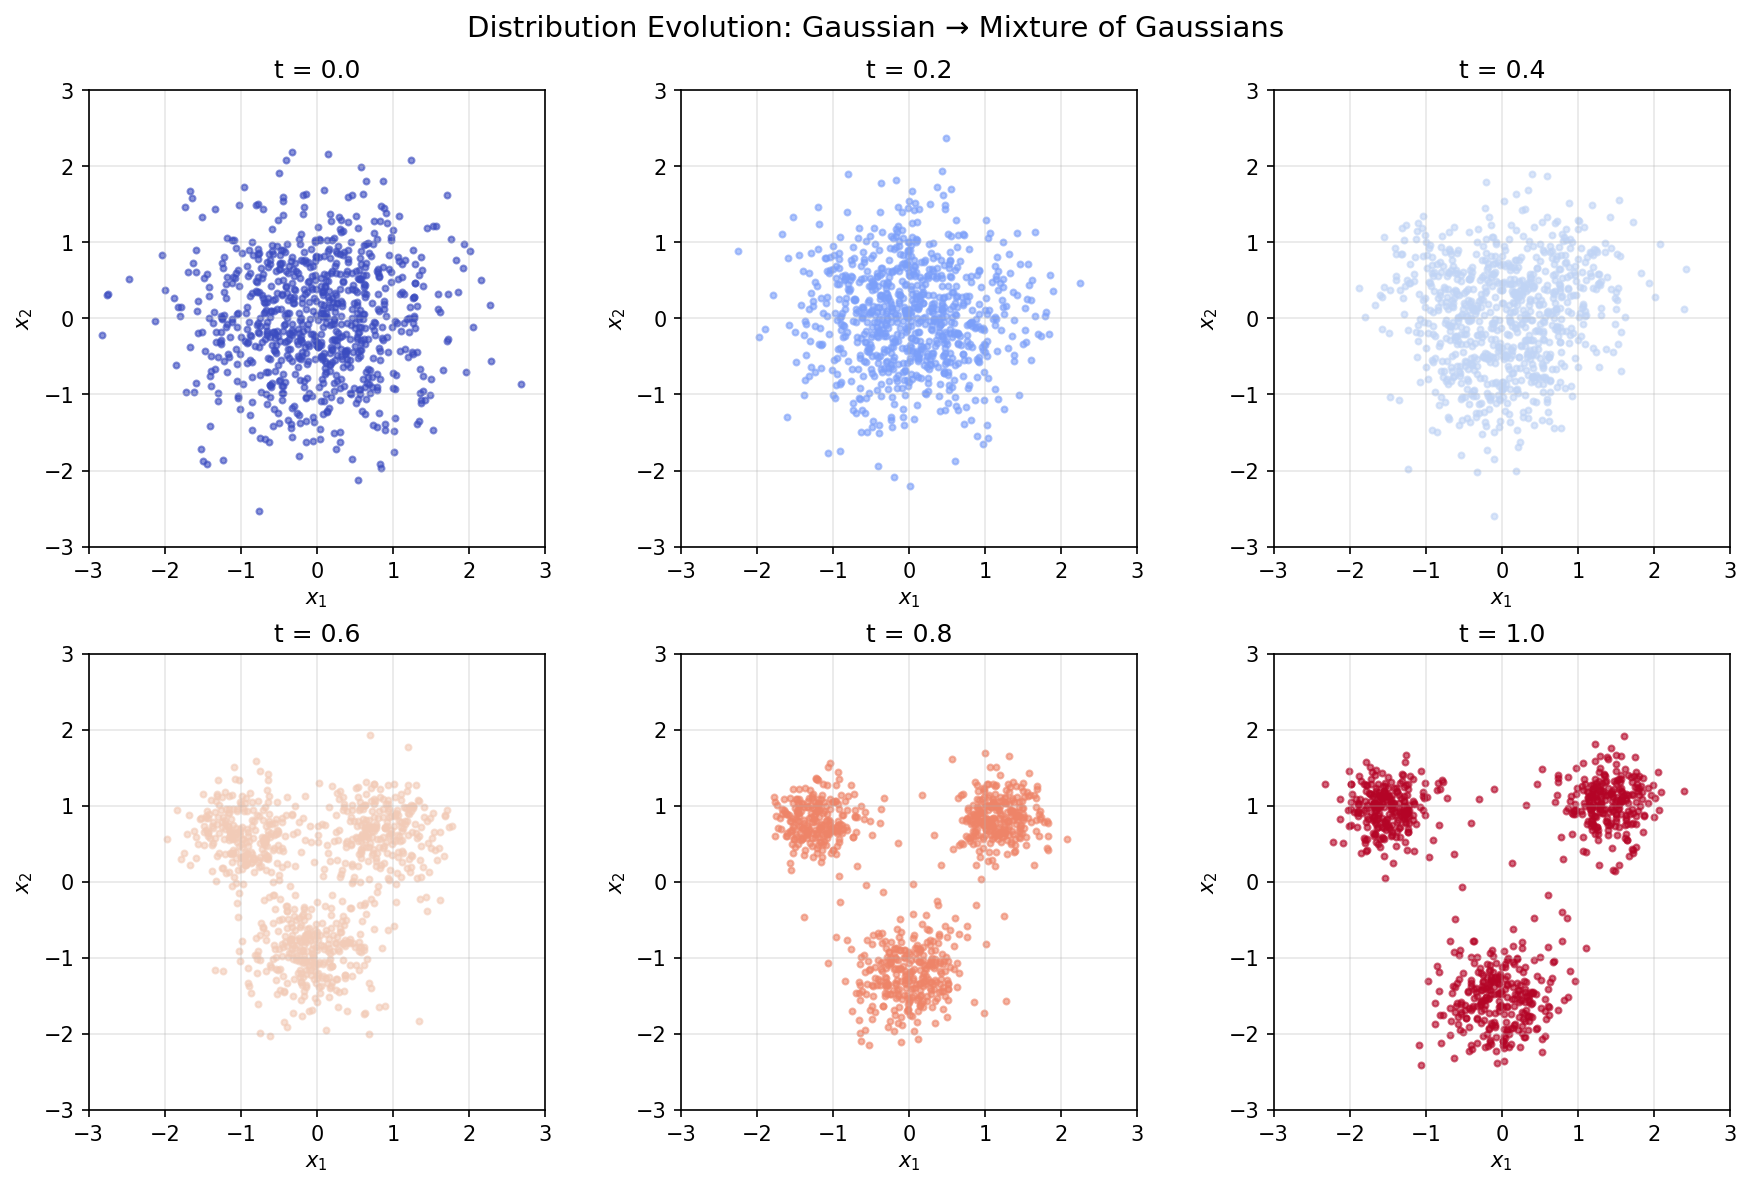

In [8]:
# Plot distribution evolution
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

# Color gradient from blue to red
colors = plt.cm.coolwarm(np.linspace(0, 1, len(times)))

for ax, t, color in zip(axes, times, colors):
    samples = distributions[t]
    ax.scatter(samples[:, 0], samples[:, 1], s=8, alpha=0.6, c=[color])
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_title(f't = {t:.1f}', fontsize=12)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

plt.suptitle('Distribution Evolution: Gaussian → Mixture of Gaussians', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Combined Visualization: Velocity Field + Trajectories + Distributions

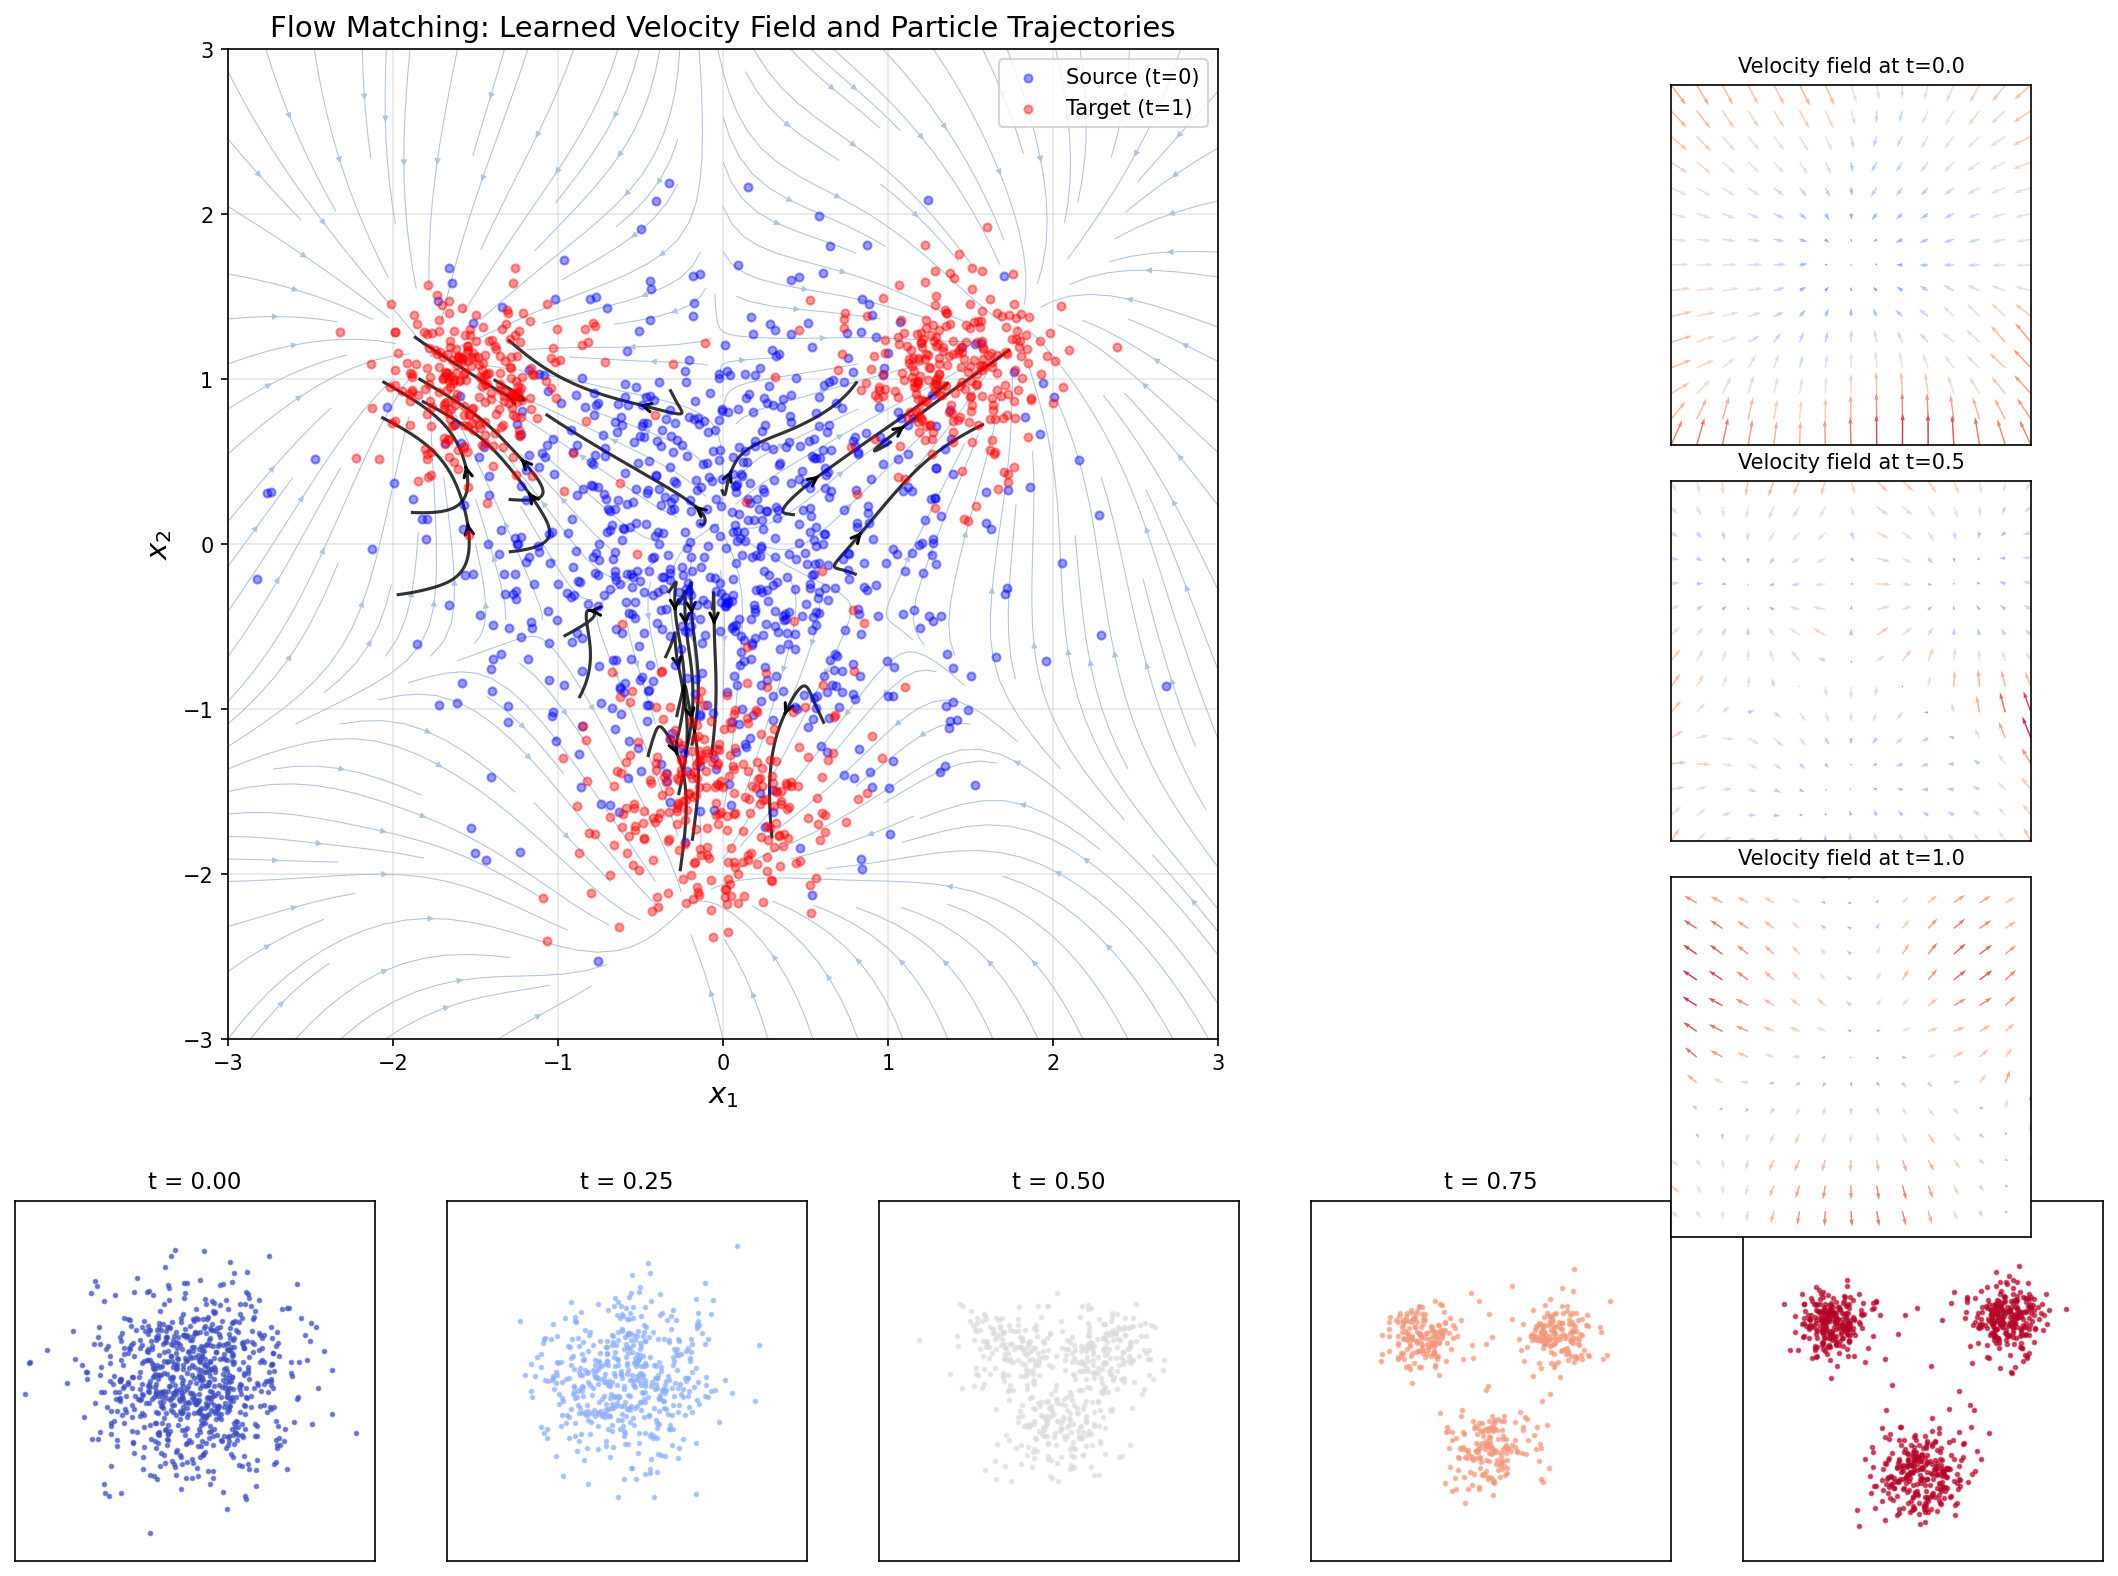

In [9]:
# Create a comprehensive figure
fig = plt.figure(figsize=(16, 12))

# Main plot: trajectories with velocity field
ax_main = fig.add_axes([0.1, 0.35, 0.55, 0.55])

# Velocity field streamlines at t=0.5
x = np.linspace(-3, 3, 30)
y = np.linspace(-3, 3, 30)
X, Y = np.meshgrid(x, y)
points = np.column_stack([X.ravel(), Y.ravel()])
points_t = torch.tensor(points, dtype=torch.float32, device=device)

# Average velocity field over time
U_avg = np.zeros_like(X)
V_avg = np.zeros_like(Y)
for t_val in [0.25, 0.5, 0.75]:
    t_t = torch.full((len(points), 1), t_val, dtype=torch.float32, device=device)
    with torch.no_grad():
        v = model(points_t, t_t).cpu().numpy()
    U_avg += v[:, 0].reshape(X.shape) / 3
    V_avg += v[:, 1].reshape(X.shape) / 3

magnitude = np.sqrt(U_avg**2 + V_avg**2)

# Streamplot (without alpha - use lighter colormap instead)
strm = ax_main.streamplot(X, Y, U_avg, V_avg, color='lightsteelblue', 
                          density=1.5, linewidth=0.5, arrowsize=0.6)

# Plot selected trajectories with emphasis
n_highlight = 20
highlight_indices = np.random.choice(len(trajectories), n_highlight, replace=False)

for idx in highlight_indices:
    t, traj = trajectories[idx]
    # Plot trajectory
    ax_main.plot(traj[:, 0], traj[:, 1], 'k-', lw=1.5, alpha=0.8)
    # Add arrow at midpoint
    mid = len(t) // 2
    dx = traj[mid+1, 0] - traj[mid, 0]
    dy = traj[mid+1, 1] - traj[mid, 1]
    ax_main.annotate('', xy=(traj[mid+1, 0], traj[mid+1, 1]), 
                     xytext=(traj[mid, 0], traj[mid, 1]),
                     arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# Plot start and end distributions
source = distributions[0.0]
target = distributions[1.0]
ax_main.scatter(source[:, 0], source[:, 1], c='blue', s=15, alpha=0.4, label='Source (t=0)', zorder=3)
ax_main.scatter(target[:, 0], target[:, 1], c='red', s=15, alpha=0.4, label='Target (t=1)', zorder=3)

ax_main.set_xlim(-3, 3)
ax_main.set_ylim(-3, 3)
ax_main.set_xlabel('$x_1$', fontsize=14)
ax_main.set_ylabel('$x_2$', fontsize=14)
ax_main.set_title('Flow Matching: Learned Velocity Field and Particle Trajectories', fontsize=14)
ax_main.legend(loc='upper right', fontsize=10)
ax_main.set_aspect('equal')
ax_main.grid(True, alpha=0.3)

# Bottom row: time snapshots
snapshot_times = [0.0, 0.25, 0.5, 0.75, 1.0]
for i, t in enumerate(snapshot_times):
    ax = fig.add_axes([0.08 + i*0.18, 0.05, 0.15, 0.22])
    
    if t in distributions:
        samples = distributions[t]
    else:
        samples = get_distribution_at_time(model, 500, t)
    
    color = plt.cm.coolwarm(t)
    ax.scatter(samples[:, 0], samples[:, 1], s=3, alpha=0.6, c=[color])
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_title(f't = {t:.2f}', fontsize=11)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

# Right side: velocity field at different times
vf_times = [0.0, 0.5, 1.0]
for i, t in enumerate(vf_times):
    ax = fig.add_axes([0.72, 0.68 - i*0.22, 0.25, 0.2])
    
    x = np.linspace(-3, 3, 15)
    y = np.linspace(-3, 3, 15)
    X, Y = np.meshgrid(x, y)
    points = np.column_stack([X.ravel(), Y.ravel()])
    points_t = torch.tensor(points, dtype=torch.float32, device=device)
    t_t = torch.full((len(points), 1), t, dtype=torch.float32, device=device)
    
    with torch.no_grad():
        v = model(points_t, t_t).cpu().numpy()
    
    U = v[:, 0].reshape(X.shape)
    V = v[:, 1].reshape(X.shape)
    mag = np.sqrt(U**2 + V**2)
    
    ax.quiver(X, Y, U, V, mag, cmap='coolwarm', scale=50, alpha=0.8)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_title(f'Velocity field at t={t:.1f}', fontsize=10)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

## 7. Clean Publication-Ready Figure

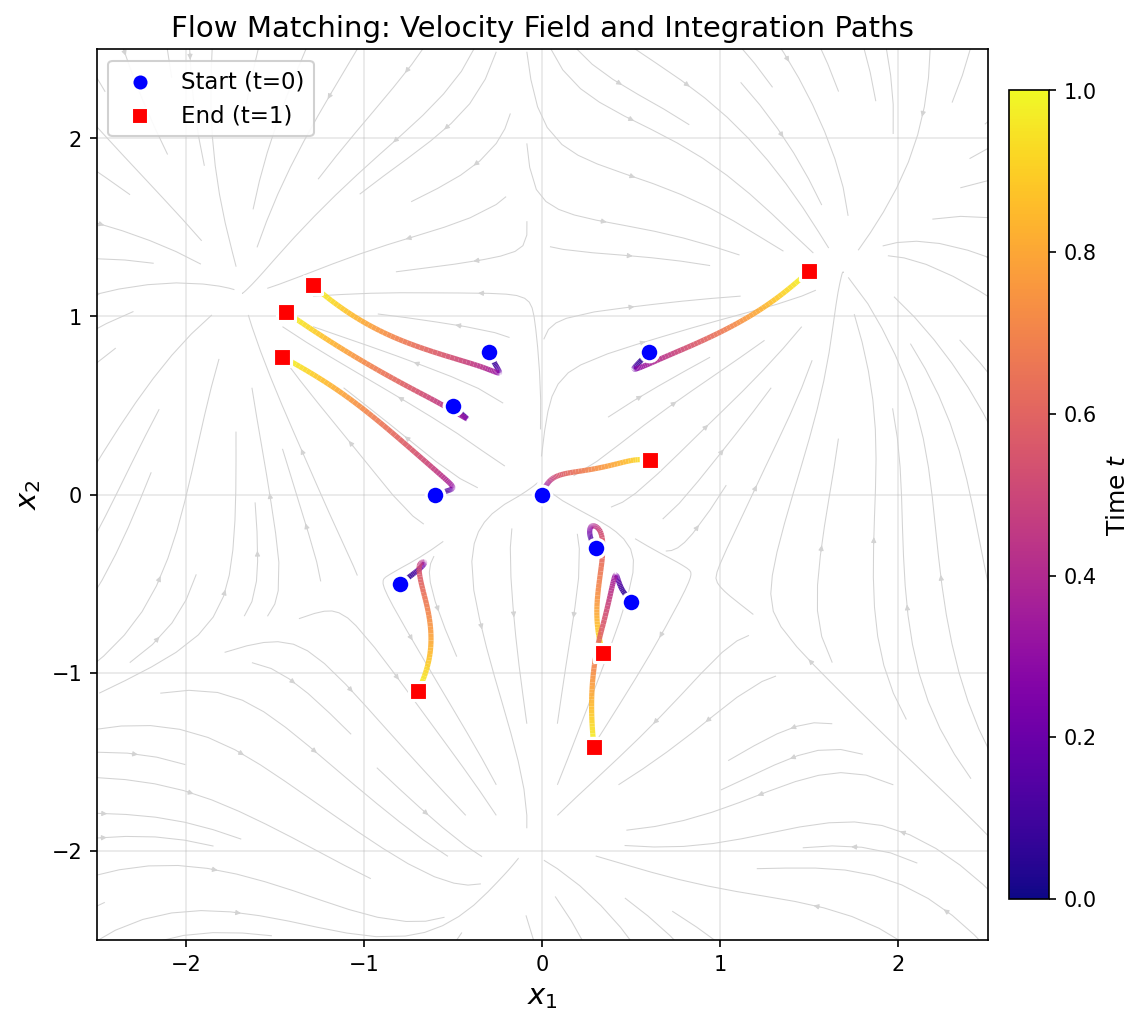

In [10]:
# Create a clean, publication-ready figure
fig, ax = plt.subplots(figsize=(8, 8))

# Light gray streamlines for velocity field
x = np.linspace(-3, 3, 25)
y = np.linspace(-3, 3, 25)
X, Y = np.meshgrid(x, y)
points = np.column_stack([X.ravel(), Y.ravel()])
points_t = torch.tensor(points, dtype=torch.float32, device=device)
t_t = torch.full((len(points), 1), 0.5, dtype=torch.float32, device=device)

with torch.no_grad():
    v = model(points_t, t_t).cpu().numpy()

U = v[:, 0].reshape(X.shape)
V = v[:, 1].reshape(X.shape)

# Streamlines
ax.streamplot(X, Y, U, V, color='lightgray', density=1.2, linewidth=0.5, arrowsize=0.5)

# Select a few trajectories to highlight
highlight_starts = np.array([
    [-0.5, 0.5],
    [0.3, -0.3],
    [-0.8, -0.5],
    [0.6, 0.8],
    [0.0, 0.0],
    [-0.3, 0.8],
    [0.5, -0.6],
    [-0.6, 0.0],
])

# Custom colormap for trajectories
cmap_traj = plt.cm.plasma

for i, x0 in enumerate(highlight_starts):
    t, traj = integrate_trajectory(model, x0, n_steps=80)
    
    # Plot with color gradient
    points_line = traj.reshape(-1, 1, 2)
    segments = np.concatenate([points_line[:-1], points_line[1:]], axis=1)
    
    from matplotlib.collections import LineCollection
    lc = LineCollection(segments, cmap=cmap_traj, alpha=0.9)
    lc.set_array(t[:-1])
    lc.set_linewidth(2.5)
    ax.add_collection(lc)
    
    # Markers
    ax.scatter(traj[0, 0], traj[0, 1], c='blue', s=80, zorder=10, 
               edgecolors='white', linewidths=1.5, marker='o')
    ax.scatter(traj[-1, 0], traj[-1, 1], c='red', s=80, zorder=10, 
               edgecolors='white', linewidths=1.5, marker='s')

# Add time colorbar
sm = plt.cm.ScalarMappable(cmap=cmap_traj, norm=plt.Normalize(0, 1))
cbar = plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Time $t$', fontsize=12)

# Labels
ax.scatter([], [], c='blue', s=60, marker='o', label='Start (t=0)', edgecolors='white')
ax.scatter([], [], c='red', s=60, marker='s', label='End (t=1)', edgecolors='white')
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)

ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_xlabel('$x_1$', fontsize=14)
ax.set_ylabel('$x_2$', fontsize=14)
ax.set_title('Flow Matching: Velocity Field and Integration Paths', fontsize=14)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

This notebook visualizes flow matching by:

1. **Training a velocity network** that learns to transport samples from a Gaussian to a mixture of Gaussians
2. **Visualizing the velocity field** at different times showing how the field guides particles
3. **Integrating particle trajectories** to show actual paths through the velocity field
4. **Showing distribution evolution** at multiple time snapshots

Key observations:
- The velocity field is time-dependent, changing as particles move
- Particles starting close together may end up in different modes of the target
- The flow "splits" the source distribution into the multiple modes of the target